# Starbucks Customers Segmentation

**Table of Contents:**



1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling & Evaluation
5. Discussion & Conclusion

<!-- 1. [Business Understanding](#business_understanding)
2. [Data Understanding](#data_understanding)  
3. [Data Preparation](#data_preparation)
4. [Modeling & Evaluation](#modeling_evaluation)
5. [Discussion & Conclusion](#discussion_conclusion) -->

# Business Understanding 
Starbucks Corporation is an American coffee company. Today, it operates more than 30,000 retail stores in 80 markets around the world.[[1]](https://www.starbucks.com/about-us/company-information/starbucks-company-profile) The company hence is a big player in a vigorously competitive industry. One approach to retain customers is its [Starbucks Reward Program](https://www.starbucks.com/rewards/). Members of the program receive promotional offers. The company then hopes to use the data collected on its customer behavior to create business value and make data-driven decisions on how it engages with its customers base.

### 1.1. Project Overview

Work in this notebook is related to [Udacity's Data Scientist](https://www.udacity.com/course/data-scientist-nanodegree--nd025?utm_source=gsem_brand&utm_medium=ads_n&utm_campaign=8305564283_c&utm_term=85684766815_sa&utm_keyword=udacity%20data%20science_e&gclid=CjwKCAiA3abwBRBqEiwAKwICA4Cgp53FH7YGsEl-Jd_7to46zhiH3nTGxkv4fpPBaND6bK1tASWO-BoCUeoQAvD_BwE) capstone project. The motivation behind this project is to propose a solution that helps the company in forming a better understanding of its customers base. In this project, an unsupervised learning technique will be used to segment customers and measure how each segment behave during different periods of the test. In particular, [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) clustering will be used. The provided dataset of courses will go through different phases at first before being ready for modeling. Starting with cleaning and ending with the final dataset grouped by customer profiles with their data aggreated.

Here's a high-level overview of the workflow followed in this project:
1. Define the problem in-hands and measurement criterias.
* Explore, understand, and clean the provided datasets.
* Prepare final dataset grouped by customers.
* Transform final dataset appropriately before fitting model.
* Fit model on final dataset and predict cluster labels.
* Explore distributions among formed clusters.
* Discuss outcomes and make recommendations.

### 1.2. Problem Statement

The company currently promotes products to customers with no prior knowledge of their segments. It is possible hence to analyse the data to find patterns in customer behaviors. This helps the company in aiming and tailoring its marketing efforts and resources to consumers who exhibit similar characteristics and are considered most likely to opt in for business's offerings. This form of target marketing is important because it helps the company by maximizing revenue while maintaining promotional campaigns cost smartly low. To do this, an unsupervised learning technique will be used to cluster customers into groups that can be be investigated separately to better understand their qualities and engage them accordingly.

### 1.3. Measurement Criterias

When speaking about measurement criterias, two categories come to mind; _business metrics_ which assist in making decisions from a business point of view, and _technical metrics_ which assist in making assessment of the implementation of the algorithm used to cluster data.

#### 1.3.1. Business Metrics

All features will be investigated as much as possible, but there are two main themes used drive decisions made in this regard:

`1` Distinguish the difference between how customers behave during non-promotional periods and how they behave when they are prompted to do so during promotionals periods. To measure this, [**R**ecency-**F**requency-**M**onetary Analysis](https://en.wikipedia.org/wiki/RFM_(market_research)) for examining customer value is used. In this model, recency, frequency and monetary values are assigned a score from one to five based on quantiles partition dividing range of values into equal-sized intervals. The RFM score is then obtained by taking the average of all three scores.

$$\textrm{RFM}_{score}={\textrm{recency}_{score}+\textrm{frequency}_{score}+\textrm{monetary}_{score}\over3}$$

`2` Identify which customers react preferably to which types of offers. To measure this, offer view and completion rates will be used where the cardinalities of corresponding sets are divided by cardinalities of relevant sets.

$$\textrm{view rate}={n(\textrm{offer viewed})\over{n(\textrm{offer received})}}\;\;\;\;\;\;\;\;\textrm{completion rate}={n(\textrm{offer completed})\over{n(\textrm{offer viewed})}}$$

#### 1.3.1. Technical Metrics

For the algorithm chosen in this problem, K-Means, two appropriate methods will be used find the optimal number of clusters $k$ and to assess the model implementations; silhouette coefficient (SC) analysis and within-cluster Sum of Squared Errors (SSE) analysis.

`1` Silhouette Coefficient (SC) analysis is a way to measure how close each point in a cluster is to the points in its neighboring clusters. Its a neat way to find out the optimum value for k during k-means clustering. Silhouette values lies in the range of [-1, 1]. A value of +1 indicates that the sample is far away from its neighboring cluster and very close to the cluster its assigned. Similarly, value of -1 indicates that the point is close to its neighboring cluster than to the cluster its assigned. And, a value of 0 means at the boundary of the distance between the two cluster. Value of +1 is ideal and -1 is least preferred. Hence, higher the value better is the cluster configuration. [[2]](https://kapilddatascience.wordpress.com/2015/11/10/using-silhouette-analysis-for-selecting-the-number-of-cluster-for-k-means-clustering/)

Mathematically, for one data point $i$ where $a(i)$ represents the calculated mean distance of point $i$ with regard to to all other points in the cluster it was assigned and $b(i)$ represents the calculated mean distance of point $i$ with regard to to all points in its closest neighboring cluster, silhouette is defined:

$$s(i)={b(i)-a(i)\over\textrm{max}\{b(i),a(i))\}}$$

Therefore, it is clear from the above equation that $$-1\leq{s(i)}\leq1$$

Then, for one value representing the silhouette score that used for assessment of clustering outcomes, where $\bar{s}(k)$ represents the mean $s(i)$ over all data of the entire dataset for a specific number of clusters $k$, silhouette coefficient is defined:

$$SC=\textrm{max}_k\{\bar{s}(k)\}$$

`2` Sum of Squared Errors (SSE) analysis is a way to measure variability (dispersion) within a cluster by taking the sum of the squared differences between each data point and its cluster's mean, and therefore defined where $x_i$ is the $i$th data point and $n$ is the total number of data points: [[3]](https://hlab.stanford.edu/brian/error_sum_of_squares.html)

$$SSE=\sum_{i=1}^{n}x_i^2-{1\over{n}}\Bigg(\sum_{i=1}^{n}x_i^2\Bigg)^2$$

SSE tends to decrease toward 0 as $k$-value increase because then each data point is its own cluster and there is no error between it and the mean of its cluster. The elbow method is then applied by plotting SSE for a range of $k$-values where where one should choose a $k$-value after which variability starts to have diminishing returns. [[4]](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)

# 2 Data Understanding

This data set contains simulated data that mimics customer behavior on the Starbucks Rewards mobile app. Once every few days, Starbucks sends out an offer to users of the mobile app. An offer can be merely an advertisement for a drink (informational) or an actual offer such as a discount or BOGO (buy one get one free). This data set is a simplified version of the real Starbucks app because the underlying simulator only has one product whereas Starbucks actually sells dozens of products.

The data is contained in three files mentioned below in brief and will be discussed in details later.

* `data/portfolio.json` - containing meta data about the promotions offered by the company.
* `data/profile.json` - demographic data about members enrolled in the reward program.
* `data/transcript.json` - records for transactions, offers received, offers viewed, and offers completed

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import utilities as u

from IPython.display import display
import pandas as pd
import numpy as np
import json
import time

from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('ggplot')
%matplotlib inline

import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

Read the Json files 

In [2]:
# Read in the json files
from pathlib import Path
data_dir = Path.cwd() / 'Dataset'
portfolio = pd.read_json(data_dir / 'portfolio.json', orient='records', lines=True)
profile = pd.read_json(data_dir / 'profile.json', orient='records', lines=True)
transcript = pd.read_json(data_dir / 'transcript.json', orient='records', lines=True)

### 2.1. `portfolio` Dataset

**Schema:**  
0. `id` (str) - offer id
* `offer_type` (str) - type of offer; bogo, discount, or informational
* `difficulty` (int) - minimum required to be spent to complete an offer
* `reward` (int) - reward given for completing an offer
* `duration` (int) - time in days for an offer to be open
* `channels` (list) - communication channels used to market an offer.

In [3]:
portfolio.head()

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [4]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [5]:
# Check null values
u.compute_null_pct(portfolio)

    column  count  pct
    reward      0  0.0
  channels      0  0.0
difficulty      0  0.0
  duration      0  0.0
offer_type      0  0.0
        id      0  0.0


**Conclusion:**

This dataset contains meta data about promotions offered by the company. Every offer has a minimum required to be spent by a customer to complete an offer represented by `difficulty` and therfore be eligible for the `reward`. Also, every offer has a validity period represented by `duration` after which it expires.

The above is true for offers with offer type "bogo" and "discount". However, for "informational" offers while they have a `duration`, their `difficulty` and `reward` are zero since these offers are merely providing information about a product. This means they are not tracked for completion in `transcript`.

There are 10 rows (representing 10 types of offers) and 6 columns with no missing or null values. Very little cleaning will be performed on this dataset.

### 2.2. `profile` Dataset

**Schema:**
0. `age` (int) - age of the customer
* `became_member_on` (int) - date when customer created an app account
* `gender` (str) - gender of the customer; M, F, or O.
* `id` (str) - customer id
* `income` (float) - income of customer

In [6]:
profile.head()

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [7]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB


In [8]:
# Check null values
u.compute_null_pct(profile)

          column  count   pct
          gender   2175 12.79
             age      0  0.00
              id      0  0.00
became_member_on      0  0.00
          income   2175 12.79


In [9]:
# Check
profile[profile.gender.isnull() == True].head(10) # this code is used to check the first 10 rows of the profile dataset where thegender column has null values      

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
6,None,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,None,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
9,None,118,8974fc5686fe429db53ddde067b88302,20161122,NaN
10,None,118,c4863c7985cf408faee930f111475da3,20170824,NaN
11,None,118,148adfcaa27d485b82f323aaaad036bd,20150919,NaN
17,None,118,744d603ef08c4f33af5a61c8c7628d1c,20170801,NaN
23,None,118,2b826eba31074a059d63b0ae8f50b7d5,20170907,NaN


In [10]:
# value_counts of `income` where `gender` is null
profile[profile.gender.isnull() == True].income.value_counts(dropna=False)
# it will show the count of each unique value in the `income` column where the `gender` column has null values, including the count of null values if there are any.    


income
NaN    2175
Name: count, dtype: int64

In [11]:
# value_counts of `age` where `gender` is null
profile[profile.gender.isnull() == True].age.value_counts()

age
118    2175
Name: count, dtype: int64

This simply shows that for the the 2175 profiles where `gender` is null, `income` is also null, and `age` is set to 118. Indicating a problem with these records.

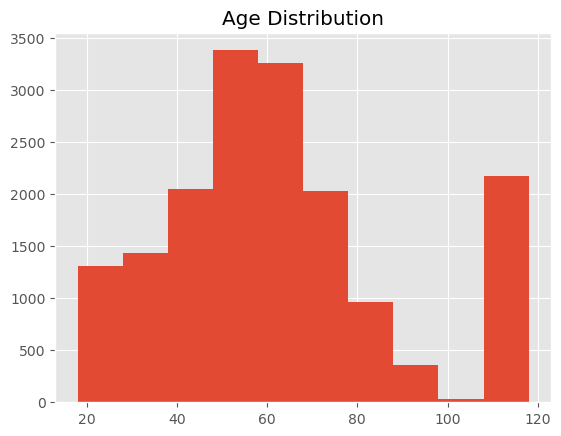

In [12]:
# Check age distribution
#plt.figure(figsize=(17,4))
plt.hist(profile.age);
plt.title('Age Distribution');

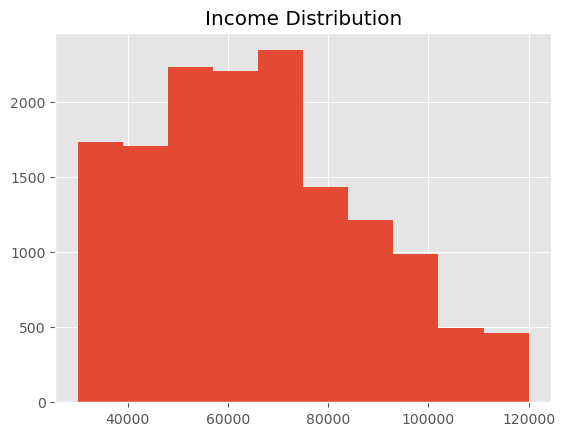

In [13]:
# Check `income` distribution
plt.hist(profile.income.dropna());
plt.title('Income Distribution');

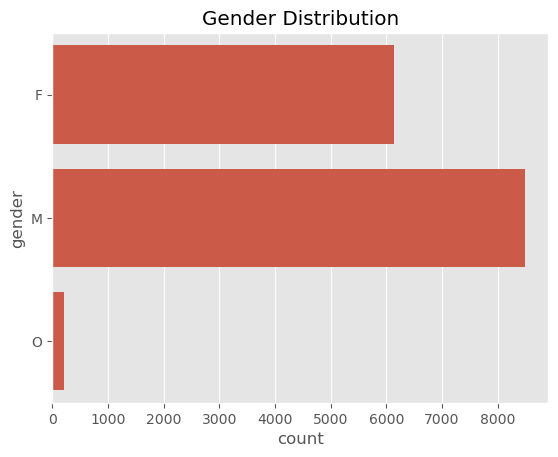

In [14]:
sns.countplot(profile.gender);
plt.title('Gender Distribution');

In [15]:
profile.gender.value_counts()

gender
M    8484
F    6129
O     212
Name: count, dtype: int64

**Conclusion:**

This dataset contains demographic data about members enrolled in the reward program with self-explanatory features. There are 17,000 rows (representing 17,000 customer profiles) and 5 columns. There are 2175 problematic rows with missing values and clear outliers. Aside from that, very little cleaning is required on this dataset.

### 2.2. `transcript` Dataset

**Schema:**
* `event` (str) - record description; transaction, offer received, offer viewed, or offer completed.
* `person` (str) - customer id.
* `time` (int) - time in hours since start of test. The data begins at time t=0.
* `value` - (dict) - either an offer id or transaction amount depending on the record.

In [16]:
transcript.tail()

,person,event,value,time
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714
306533,c02b10e8752c4d8e9b73f918558531f7,transaction,{'amount': 4.05},714


In [17]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB


In [18]:
transcript.event.value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [19]:
transcript.loc[transcript.event == 'transaction'].value.head()

12654    {'amount': 0.8300000000000001}
12657                 {'amount': 34.56}
12659                 {'amount': 13.23}
12670                 {'amount': 19.51}
12671                 {'amount': 18.97}
Name: value, dtype: object

In [20]:
transcript.loc[transcript.event == 'offer received'].value.head()

0    {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1    {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2    {'offer id': '2906b810c7d4411798c6938adc9daaa5'}
3    {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
4    {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
Name: value, dtype: object

In [21]:
transcript.loc[transcript.event == 'offer viewed'].value.head()

12650    {'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}
12651    {'offer id': '5a8bc65990b245e5a138643cd4eb9837'}
12652    {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
12653    {'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}
12655    {'offer id': '5a8bc65990b245e5a138643cd4eb9837'}
Name: value, dtype: object

In [22]:
transcript.loc[transcript.event == 'offer completed'].value.head()

12658    {'offer_id': '2906b810c7d4411798c6938adc9daaa5...
12672    {'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...
12679    {'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...
12692    {'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...
12697    {'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...
Name: value, dtype: object

In [23]:
transcript.loc[transcript.person == '78afa995795e4d85b5d9ceeca43f5fef']

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
15561,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},6
47582,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.89},132
47583,78afa995795e4d85b5d9ceeca43f5fef,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,132
49502,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 17.78},144
53176,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168
85291,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},216
87134,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.67},222
92104,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 29.72},240
141566,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 23.93},378


In [24]:
# Check test period
print(transcript.time.max(), 'hours')
print(transcript.time.max() / 24, 'days')

714 hours
29.75 days


**Conclusion:**

This dataset contains records of activities related to the test simulated. Each record is time-stamped since the start of the test. The test start at t=0 and ends at t=714 (≈ 30 days). The nature of each record is described using `event`. The `value` column holds a value based on the `event` column. For offer received, viewed, and completed, the offer id is recorded. For transaction, the amount is recorded. Although this dataset is somehow abstract, 306534 rows and 4 columns, most of the cleaning process will be performed on this dataset.

<a id='data_preparation'></a>
## 3. Data Preparation

In this section, different compantions of techniques will be performed to produce the final dataset ready for modeling next section. Starting with cleaning the provided datasets, and then merging and aggregating data to form the final dataset. The final dataset will be grouped by customers profiles. The diagram below provide a high-level overview of the workflow followed in this project to produce final dataframe `coe` which stands for **C**ustomer-**O**ffer **E**ngagement.

<img src="images/workflow.png" style="margin: 10px 0px"/>
<center>Figure 1: Overview of Dataframes Manipulation</center>

# Data Cleaning

#### 3.1.1. `portfolio` Dataset

Starting be renaming columns `id` and `reward` to `offer_id` and `offered_reward` respectively. This serves readability. The latter in particular to make it distinguishable from a later added column `redeemed_reward`.

In [25]:
# Rename specified columns
portfolio.rename(columns={
    'id': 'offer_id',
    'reward': 'offered_reward'}, inplace=True)

One-hot encoding for columns `channels` and `offer_type` using utility function `one_hot_encoder`.

In [26]:
# One-hot encode `channel` column
portfolio = u.one_hot_encoder(
    df = portfolio,
    target_column = 'channels',
    categories = ['web','email','mobile','social'],
    prefix = 'channel')

# One-hot encode `offer_type` column
portfolio = u.one_hot_encoder(
    df = portfolio,
    target_column = 'offer_type',
    categories = ['discount','bogo','informational'],
    prefix = 'type')

Convert `offer_id` to integers, again for readability, while retaining the mapping dictionary later used to map offer ids in `transcript`. All done with help of utility function `label_encoder`.

In [27]:
# Convert `offer_id` to integers
portfolio, offer_id_dict = u.label_encoder(
    df = portfolio,
    target_column = 'offer_id',
    start = 1,
    step = 1)

In [28]:
offer_id_dict

{'ae264e3637204a6fb9bb56bc8210ddfd': 1,
 '4d5c57ea9a6940dd891ad53e9dbe8da0': 2,
 '3f207df678b143eea3cee63160fa8bed': 3,
 '9b98b8c7a33c4b65b9aebfe6a799e6d9': 4,
 '0b1e1539f2cc45b7b9fa7c272da2e1d7': 5,
 '2298d6c36e964ae4a3e7e9706d1fb8c2': 6,
 'fafdcd668e3743c1bb461111dcafc2a4': 7,
 '5a8bc65990b245e5a138643cd4eb9837': 8,
 'f19421c1d4aa40978ebb69ca19b0e20d': 9,
 '2906b810c7d4411798c6938adc9daaa5': 10}

In [29]:
portfolio.head()

,offered_reward,difficulty,duration,offer_id,channel_web,channel_email,channel_mobile,channel_social,type_discount,type_bogo,type_informational
0,10,10,7,1,0,1,1,1,0,1,0
1,10,10,5,2,1,1,1,1,0,1,0
2,0,0,4,3,1,1,1,0,0,0,1
3,5,5,7,4,1,1,1,0,0,1,0
4,5,20,10,5,1,1,0,0,1,0,0


In [30]:
u.compute_null_pct(portfolio)

            column  count  pct
    offered_reward      0  0.0
        difficulty      0  0.0
          duration      0  0.0
          offer_id      0  0.0
       channel_web      0  0.0
     channel_email      0  0.0
    channel_mobile      0  0.0
    channel_social      0  0.0
     type_discount      0  0.0
         type_bogo      0  0.0
type_informational      0  0.0


#### 3.1.2. `profile` Dataset

Rename `id` column to `customer_id`

In [31]:
profile.rename(columns={'id': 'customer_id'}, inplace=True)

Convert `became_member_on` column to standard `datetime` object. This will be used then to add calculated `days_member` column and then dropped.

In [32]:
# Convert `became_member_on` to standard `datetime` object
profile.became_member_on = pd.to_datetime(profile.became_member_on, format='%Y%m%d')

# Add calculated 'days_member' column
profile['days_member'] = (pd.to_datetime('today') - profile['became_member_on']).dt.days.astype(int)

# Drop `became_member_on`
profile.drop(columns='became_member_on', inplace=True)

In regards to the 2175 profiles with missing values discussed earlier, the decision was to simply drop them. Also, dropping 212 profiles with 'other' gender. This to make it much easier to just remap 'male' and 'female' gender with binary values in one column. It's important to retain their ids in order to later remove corresponding activies in `transcript`.

In [33]:
# Retain `customer_id` of rows to be deleted to later remove corresponding rows in `transcript`
dropped_profiles = profile[
    (profile.gender.isnull() == True) | (profile.gender == 'O')].customer_id.values

# Drop rows using the list produced in `dropped_profiles` above
profile.drop(profile[profile.customer_id.isin(dropped_profiles) == True].index, inplace=True)

# Reset index
profile.reset_index(drop=True, inplace=True)

Now `gender` column can be simply remapped using binary values.

In [34]:
# Remap `gender` column using binary values
profile.gender = profile.gender.map({'F':0, 'M':1})

Convert `customer_id` to integers, again for readability, while retaining the mapping dictionary later used to map customer ids in `transcript`. All done with help of utility function `label_encoder`.

In [35]:
# Convert `customer_id` to integers
profile, customer_id_dict = u.label_encoder(
    df = profile,
    target_column = 'customer_id',
    start = 1,
    step = 1)

In [36]:
# Preview 5 element
dict(list(customer_id_dict.items())[0:5])

{'0610b486422d4921ae7d2bf64640c50b': 1,
 '78afa995795e4d85b5d9ceeca43f5fef': 2,
 'e2127556f4f64592b11af22de27a7932': 3,
 '389bc3fa690240e798340f5a15918d5c': 4,
 '2eeac8d8feae4a8cad5a6af0499a211d': 5}

In [37]:
profile.head()

,gender,age,customer_id,income,days_member
0,0,55,1,112000.0,3212
1,0,75,2,100000.0,3279
2,1,68,3,70000.0,2927
3,1,65,4,53000.0,3003
4,1,58,5,51000.0,3093


In [38]:
u.compute_null_pct(profile)

     column  count  pct
     gender      0  0.0
        age      0  0.0
customer_id      0  0.0
     income      0  0.0
days_member      0  0.0


#### 3.1.2. `Transcript` Dataset

Rename `person` column to `customer_id`

In [39]:
# Rename `person` column to `customer_id`
transcript.rename(columns={'person': 'customer_id'}, inplace=True)

Drop rows with `customer_id` corresponding to deleted users in `profile`.

In [40]:
# Drop rows with `customer_id` corresponding to deleted users in `profile`
transcript = transcript[transcript.customer_id.isin(dropped_profiles) == False]

Map `customer_id` with previously created `customer_id_dict`

In [41]:
# Map `customer_id` with previously created `customer_id_dict`
transcript.customer_id = transcript.customer_id.apply(lambda x: customer_id_dict[x])

To deal with `value` column, two new columns are created. `value_type` and `actual_value`. Their entries are derived by applying a function along each row to extract and hence separate data. Original `value` column is then dropped.  

In [42]:
# Add column `value_type`
transcript['value_type'] = transcript.value.apply(lambda x : list(x.keys())[0])

# Add column `actual_value`
transcript['actual_value'] = transcript.value.apply(lambda x : list(x.values())[0])

# Drop `value` column
transcript.drop(columns='value', inplace=True)

In [43]:
transcript.head(2)

,customer_id,event,time,value_type,actual_value
0,2,offer received,0,offer id,9b98b8c7a33c4b65b9aebfe6a799e6d9
2,3,offer received,0,offer id,2906b810c7d4411798c6938adc9daaa5


In [44]:
transcript.tail(2)

,customer_id,event,time,value_type,actual_value
306531,14598,transaction,714,amount,3.61
306532,14604,transaction,714,amount,3.53


Split `transcript` dataset into offers and transactions to work on each separately.

In [45]:
# Split `transcript` dataset into offer and transaction
offers_df = transcript[transcript['event'] != 'transaction']
transactions_df = transcript[transcript['event'] == 'transaction']

Now, column `actual_value` can be renamed in each dataframe accordingly. In `offers_df` will be renamed to `offer_id`, and in `transactions_df` will be renamed to `amount`.

In [46]:
# Rename columns
offers_df.rename(columns={'actual_value': 'offer_id'}, inplace=True)
transactions_df.rename(columns={'actual_value': 'amount'}, inplace=True)

Due to this split, some coulmns are no longer needed. `value_type` in `offers_df`. `event` and `value_type` in `transactions_df`. These columns are to be dropped.  the `value` column was separated

In [47]:
# Drop unnecessary columns
offers_df.drop(columns='value_type', inplace=True)
transactions_df.drop(columns=['value_type', 'event'], inplace=True)

Now, it is possible to map `offer_id` in  `offers_df` with previously created `offer_id_dict`.

In [48]:
# Map `offer_id` with previously created `offer_id_dict`
offers_df.offer_id = offers_df.offer_id.apply(lambda x: offer_id_dict[x])

In [49]:
offers_df.head()


,customer_id,event,time,offer_id
0,2,offer received,0,4
2,3,offer received,0,10
5,4,offer received,0,9
7,5,offer received,0,3
8,6,offer received,0,5


In [50]:
u.compute_null_pct(offers_df)

     column  count  pct
customer_id      0  0.0
      event      0  0.0
       time      0  0.0
   offer_id      0  0.0


In [51]:
transactions_df.head()

,customer_id,time,amount
12654,28,0,0.83
12657,39,0,34.56
12659,45,0,13.23
12670,107,0,19.51
12671,123,0,18.97


In [52]:
u.compute_null_pct(transactions_df)

     column  count  pct
customer_id      0  0.0
       time      0  0.0
     amount      0  0.0


### 3.2. Data Preprocessing

Now that the four dataframes, `portfolio`, `profile`, `offers_df`, and `transactions_df` are cleaned. The process of merging and aggregating data can proceed.

The first step is merge `portfolio` to `offers_df`.

In [53]:
# Merge `portfolio` to `offers_df`
offers_df = pd.merge(offers_df, portfolio, on='offer_id')


In [54]:
offers_df.head()

,customer_id,event,time,offer_id,offered_reward,difficulty,duration,channel_web,channel_email,channel_mobile,channel_social,type_discount,type_bogo,type_informational
0,2,offer received,0,4,5,5,7,1,1,1,0,0,1,0
1,3,offer received,0,10,2,10,7,1,1,1,0,1,0,0
2,4,offer received,0,9,5,5,5,1,1,1,1,0,1,0
3,5,offer received,0,3,0,0,4,1,1,1,0,0,0,1
4,6,offer received,0,5,5,20,10,1,1,0,0,1,0,0


Three dataframes are then created based on `event`.

In [55]:
# Split `offers_df` based on `event`
received_df = offers_df[offers_df['event']=='offer received']
viewed_df = offers_df[offers_df['event']=='offer viewed']
completed_df = offers_df[offers_df['event']=='offer completed']

To keep things clean, new auxiliary dataframe `aux_df` is created as a copy of `received_df` which will be the workspace for all preprocessing steps. Many of the columns created in this dataframe will not make it to the final dataframe grouped by customer profiles but they are useful in logical operations.

In [56]:
# Create aux_df: a copy of received_df
aux_df = received_df.copy()

Since `aux_df` is nothing but a copy of `received_df`. Simply the `event` column which only contains the value ‘offer_recieved’ can be renamed to `offer_recieved` with a value of 1.

In [57]:
# Rename `event` to `offer_received` in `aux_df`
aux_df.rename(columns={'event': 'offer_received'}, inplace=True)
aux_df.offer_received = 1

In `aux_df`, two new columns will serve as the base for all logical tests later. `offer_start_time` which is nothing but the already existing `time` column. Hence, `time` will be renamed to `offer_start_time`. The other one is `offer_end_time` which can be easily obtained by adding the offer `duratin` (in hours) to `offer_start_time`.

In [58]:
# Rename `time` to `offer_start_time` and add `offer_end_time`
aux_df.rename(columns={'time': 'offer_start_time'}, inplace=True)
aux_df['offer_end_time'] = aux_df.offer_start_time + aux_df.duration * 24

Now that the start and end time for each offer received in `aux_df` are present, a utility function `get_offer_engagements` will be applied along each row. This function takes other dataframes (`viewed_df`, `completed_df`, `transactions_df`) and extract necessary data. The function then returns a list in the form of [`offer_viewed_time`, `offer_completed_time`]. If any was missing or invaild, returns NaN in its corresponding place inside the list. Then, another utility function `expand_list_to_columns` is used to expand the output value returnd into separate columns.

It is important here to go over the assumption programmed into the function `get_offer_engagements` for a view or completion time to be valid.

An offer is considered _**viewed**_ only if done so after it has been received and during offer's duration. That means the conditions for a valid view time:  
1. `offer_viewed_time >= offer_start_time`, and
2. `offer_viewed_time <= offer_end_time`
    
An offer is considered _**completed**_ depending on the offer type:
* For bogo and discount offers, `completed_df` dataframe is used extract necessary info. The completion time must be after the time it has been viewed and during offer's duration. That means the conditions for a valid complete time in this case:
    1. `offer_completed_time >= offer_viewed_time`, and
    2. `offer_completed_time <= offer_end_time`


* For informational offers, `transactions_df` is used to extract necessary info. The way completion for informational offers is measured is by checking if the customer has made any transaction after viewing the offer and in offer's duration which assumed earlier to be the period of influence. That means the conditions for a valid complete time in this case:
    1. `transaction_time >= offer_viewed_time`, and
    2. `transaction_time <= offer_end_time`

In [59]:
# Add empty object column to store `output_value` list of function
aux_df['output_value'] = ''

# Apply u.get_offer_engagements to each row
aux_df.output_value = aux_df.apply(
    lambda x: u.get_offer_engagements(x, viewed_df, completed_df, transactions_df), axis=1)

# Expand `output_value` list to columns
aux_df = u.expand_list_to_columns(aux_df, 'output_value', {
    0: 'offer_viewed_time',
    1: 'offer_completed_time'})

In [60]:
aux_df[['offer_start_time', 'offer_end_time', 'offer_viewed_time', 'offer_completed_time']].head(15)

,offer_start_time,offer_end_time,offer_viewed_time,offer_completed_time
0,0,168,6.0,132.0
1,0,168,18.0,NaN
2,0,120,0.0,60.0
3,0,96,NaN,NaN
4,0,240,18.0,NaN
5,0,240,150.0,NaN
6,0,168,102.0,NaN
7,0,96,18.0,18.0
8,0,240,30.0,30.0
9,0,240,18.0,126.0


One feature that will be added is `response_score` which measures how fast a customer responded to an offer once viewed. The score is normalized using offer's duration and range from 0 to 1. The higher the score, the faster responsivity to an offer.

In [62]:
# Add `response_score` column

aux_df['response_score'] = (
    aux_df.offer_completed_time -
    aux_df.offer_viewed_time).apply(
    lambda x: x if x >= 0 else np.nan)

aux_df.response_score = np.round(((
    (aux_df.duration * 24) - aux_df.response_score) /
    (aux_df.duration * 24)), 2).fillna(0)

In [63]:
aux_df[['offer_viewed_time', 'offer_completed_time', 'response_score']].head(15)

,offer_viewed_time,offer_completed_time,response_score
0,6.0,132.0,0.25
1,18.0,NaN,0.00
2,0.0,60.0,0.50
3,NaN,NaN,0.00
4,18.0,NaN,0.00
5,150.0,NaN,0.00
6,102.0,NaN,0.00
7,18.0,18.0,1.00
8,30.0,30.0,1.00
9,18.0,126.0,0.55


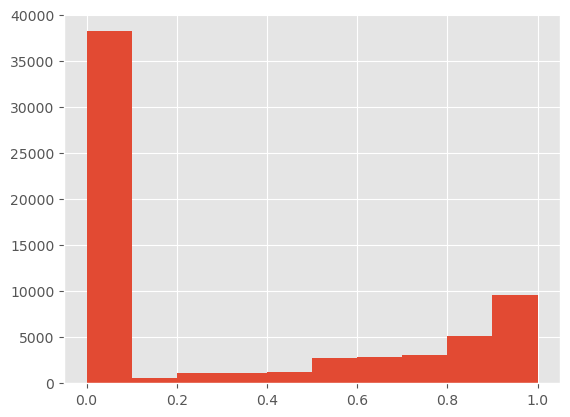

In [64]:
aux_df.response_score.hist();

Since the view and compeltion time is now present, two new columns `offer_viewed` and `offer_completed` with binery values will be added.

In [65]:
# Add `offer_viewed` and `offer_completed` columns with binery values
aux_df['offer_viewed'] = aux_df.offer_viewed_time.apply(lambda x: 0 if pd.isnull(x) else 1)
aux_df['offer_completed'] = aux_df.offer_completed_time.apply(lambda x: 0 if pd.isnull(x) else 1)

In [66]:
aux_df[['offer_viewed_time', 'offer_completed_time', 'offer_viewed', 'offer_completed']].head()

,offer_viewed_time,offer_completed_time,offer_viewed,offer_completed
0,6.0,132.0,1,1
1,18.0,NaN,1,0
2,0.0,60.0,1,1
3,NaN,NaN,0,0
4,18.0,NaN,1,0


New `redeemed_reward` columns is added by simply multiplying `offered_reward` by `offer_completed`.

In [67]:
# Add `redeemed_reward` columns
aux_df['redeemed_reward'] = aux_df.offered_reward * aux_df.offer_completed

To make things clean, three temprary (dummy) dataframes are created. Named `alpha_df`, `beta_df`, and `gamma_df`. In the first two, selection of columns are used and aggregated by sum and mean respectively. In the last, utility function `split_columns_by_offer_type` is used on a selection of columns to aggregate data by offer type.

In [68]:
# Create dummy dataframes each with different selection of columns and aggregator

alpha_df = aux_df[[
    'customer_id',
    'offer_received',
    'offer_viewed',
    'offer_completed',
    'channel_web',
    'channel_email',
    'channel_mobile',
    'channel_social',
    ]].groupby('customer_id', as_index=True).sum().fillna(0)

beta_df = aux_df[[
    'customer_id',
    'difficulty',
    'duration',
    'offered_reward',
    'redeemed_reward',
    'response_score',
    ]].groupby('customer_id', as_index=True).mean().fillna(0)

gamma_df = u.split_columns_by_offer_type(aux_df, [
    'offer_received',
    'offer_viewed',
    'offer_completed',
    'response_score',
    ])

Now, creating the final datframe `coe` which will be used for modeling by megring the above dataframes `alpha_df`, `beta_df`, and `gamma_df` to `profile`.

In [69]:
# Create the final dataset `coe`
coe = pd.merge(profile.set_index('customer_id'), alpha_df, left_index=True, right_index=True)
coe = pd.merge(coe, beta_df, left_index=True, right_index=True)
coe = pd.merge(coe, gamma_df, left_index=True, right_index=True)

coe.reset_index(inplace=True)

In this step below, sets of new features will be added using utility function `get_transactions_allotment` that will be helpful in measuring the two main points discussed in _problem statement_. The nomenclature for these features is as follows:

* Prefixes
    * `txn_`: Count of transactions.
    * `amt_`: Sum of amount.
    * `recency_`: Time of most recent transaction.
    * `frequency_`: Average time in hours between transactions.
    * `monetary_`: Average amount per transaction.
* Suffixes
    * `_overall`: Anytime during the test period.
    * `_promo`: During offer durations (regardless of view or completion).
    * `_nonpromo`: In-between (outside) offers durations

The set of `frequency_`, `recency_`, and `monetary_` features is necessary to calculate the RFM score. This [article](https://clevertap.com/blog/rfm-analysis/) was a nice guide in doing so.

In [70]:
# Add empty object column to store `output_value` list of function
coe['output_value'] = ''

# Apply u.get_transactions_allotment to each row
coe.output_value = coe.apply(
    lambda x: u.get_transactions_allotment(x, aux_df, transactions_df), axis=1)

# Expand `output_value` list to columns
coe = u.expand_list_to_columns(coe, 'output_value', {
    0: 'txn_overall',
    1: 'amt_overall',
    2: 'txn_promo',
    3: 'amt_promo',
    4: 'txn_nonpromo',
    5: 'amt_nonpromo',
    6: 'recency_promo',
    7: 'recency_nonpromo'})

# Add remaining required components for RFM score
coe['monetary_promo'] = np.round(coe.amt_promo / coe.txn_promo, 2)
coe['monetary_nonpromo'] = np.round(coe.amt_nonpromo / coe.txn_nonpromo, 2)

coe['frequency_promo'] = np.round(coe.recency_promo / coe.txn_promo, 2)
coe['frequency_nonpromo'] = np.round(coe.recency_nonpromo / coe.txn_promo, 2)

Now that the basies for RFM paradigm are present, utility function `add_rfm_scores` will be used to calculate the RFM score. This function uses `pd.qcut` to rank values in each column of `frequency_...`, `recency_...`, and `monetary_...` in 5 bins. Then, for each custmer, average of relevant values are obtained. The results are stored in two new columns `rfm_promo_score` and `rfm_nonpromo_score` with the original columns dropped from the dataframe. The scores ranges from 0 to 5. Starting from 0 which indicates no activity at all. Going up, the higher the better customer value.

In [71]:
# Run u.add_rfm_paradigm on the dataset to perform necessary computations
coe = u.add_rfm_scores(coe)

In [72]:
coe[['rfm_promo_score', 'rfm_nonpromo_score']].head()

,rfm_promo_score,rfm_nonpromo_score
0,4.67,4.00
1,2.67,4.33
2,4.33,4.00
3,1.67,0.00
4,2.33,0.00


Three more features are added; `amt_per_test_hour`: avergae spent during the test period per hour, `amt_per_member_day`: avergae spent during the test period per number of membrship days, and `amt_per_income`: avergae spent during the test period per income.

In [73]:
# Add three more calculated columns describing customers attributes
coe['amt_per_test_hour'] = np.round(coe.amt_overall / transactions_df.time.max(), 6)
coe['amt_per_member_day'] = np.round(coe.amt_overall / coe.days_member, 6)
coe['amt_per_income'] = np.round(coe.amt_overall / coe.income, 6)

Final step is to drop `customer_id` column.

In [74]:
# Drop 'customer_id' column; not needed in the model
coe.drop(columns='customer_id', inplace=True)

At this point, dataframe `coe` is ready to be used for modeling to perform customer segmentation. It has 39 features and 14608 samples. All features are numerical except `gender` which is a categorical feature represented by binary values.

In [75]:
coe.shape


(14608, 39)

In [76]:
coe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14608 entries, 0 to 14607
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   txn_overall           14608 non-null  float64
 1   amt_overall           14608 non-null  float64
 2   txn_promo             14608 non-null  float64
 3   amt_promo             14608 non-null  float64
 4   txn_nonpromo          14608 non-null  float64
 5   amt_nonpromo          14608 non-null  float64
 6   gender                14608 non-null  int64  
 7   age                   14608 non-null  int64  
 8   income                14608 non-null  float64
 9   days_member           14608 non-null  int64  
 10  offer_received        14608 non-null  int64  
 11  offer_viewed          14608 non-null  int64  
 12  offer_completed       14608 non-null  int64  
 13  channel_web           14608 non-null  int64  
 14  channel_email         14608 non-null  int64  
 15  channel_mobile     

**Schema:**
* `txn_overall`: Count of transactions made anytime during the test.
* `amt_overall`: Sum of amount spent anytime during the test.
* `txn_promo`: Count of transactions made during offer durations (regardless of view or completion).
* `amt_promo`: Sum of amount spent during offer durations (regardless of view or completion).
* `txn_nonpromo`: Count of transactions in-between (outside) offers durations.
* `amt_nonpromo`: Sum of amount spent in-between (outside) offers durations.
* `gender`: Customer's gender {0: Female, 1:Male}
* `age`: Customer's age.
* `income`: Customer's income.
* `days_member`: Number of days as a member of the program (dynamic; as of today's date).
* `offer_received`: Count of total offers received.
* `offer_viewed`: Count of total offers viewed.
* `offer_completed`: Count of total offers completed.
* `channel_web`: Count of total offer received via web.
* `channel_email`: Count of total offer received via email.
* `channel_mobile`: Count of total offer received via mobile.
* `channel_social`: Count of total offer received via social.
* `difficulty`: Average of minimum required to be spent for all offers received.  
* `duration`: Average of validity period for all offers received.
* `offered_reward`: Average of offered reward for all offers received.
* `redeemed_reward`: Average of redeemed reward for all offers received.
* `response_score`: Average of response score for all offers received.
* `bogo_offer_received`: Count of total 'bogo' offers received.
* `disc_offer_received`: Count of total 'discount' offers received.
* `info_offer_received`: Count of total 'informational' offers received.
* `bogo_offer_viewed`: Count of total 'bogo' offers viewed.
* `disc_offer_viewed`: Count of total 'discount' offers viewed.
* `info_offer_viewed`: Count of total 'informational' offers viewed.
* `bogo_offer_completed`: Count of total 'bogo' offers completed.
* `disc_offer_completed`: Count of total 'discount' offers completed.
* `info_offer_completed`: Count of total 'informational' offers completed.
* `bogo_response_score`: Average of response score for all 'bogo' offers received.
* `disc_response_score`: Average of response score for all 'discount' offers received.
* `info_response_score`: Average of response score for all 'informational' offers received.
* `rfm_promo_score`: RFM score during offer durations (regardless of view or completion).
* `rfm_nonpromo_score`: RFM score in-between (outside) offers durations.
* `amt_per_test_hour`: Average spend during the test period per hour.
* `amt_per_member_day`: Average spend during the test period per day as a member of the program.
* `amt_per_income`: Average spend during the test period per income.

In [77]:
coe.head()

,txn_overall,amt_overall,txn_promo,amt_promo,txn_nonpromo,amt_nonpromo,gender,age,income,days_member,offer_received,offer_viewed,offer_completed,channel_web,channel_email,channel_mobile,channel_social,difficulty,duration,offered_reward,redeemed_reward,response_score,bogo_offer_received,disc_offer_received,info_offer_received,bogo_offer_viewed,disc_offer_viewed,info_offer_viewed,bogo_offer_completed,disc_offer_completed,info_offer_completed,bogo_response_score,disc_response_score,info_response_score,rfm_promo_score,rfm_nonpromo_score,amt_per_test_hour,amt_per_member_day,amt_per_income
0,3.0,77.01,1.0,23.22,2.0,53.79,0,55,112000.0,3212,2,0,0,2,2,2,0,2.500000,5.500000,2.500000,0.000000,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,4.67,4.00,0.107857,0.023976,0.000688
1,7.0,159.27,6.0,135.34,1.0,23.93,0,75,100000.0,3279,4,4,3,2,4,4,3,5.000000,5.500000,5.000000,3.750000,0.390000,3.0,0.0,1.0,3.0,0.0,1.0,2.0,0.0,1.0,0.64,0.00,0.92,2.67,4.33,0.223067,0.048573,0.001593
2,3.0,57.73,1.0,18.42,2.0,39.31,1,68,70000.0,2927,4,3,2,4,4,4,1,6.250000,7.000000,2.250000,1.750000,0.347500,1.0,2.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,0.39,1.00,0.00,4.33,4.00,0.080854,0.019723,0.000825
3,3.0,36.43,3.0,36.43,0.0,0.00,1,65,53000.0,3003,6,6,5,6,6,6,3,6.666667,6.833333,4.000000,3.166667,0.405000,2.0,2.0,0.0,2.0,2.0,0.0,1.5,2.0,0.0,0.67,1.09,0.00,1.67,0.00,0.051022,0.012131,0.000687
4,4.0,15.62,4.0,15.62,0.0,0.00,1,58,51000.0,3093,3,2,1,3,3,3,2,5.666667,7.000000,1.666667,0.666667,0.183333,0.0,2.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.00,0.55,0.00,2.33,0.00,0.021877,0.005050,0.000306


In [78]:
u.compute_null_pct(coe)

              column  count  pct
         txn_overall      0  0.0
         amt_overall      0  0.0
           txn_promo      0  0.0
           amt_promo      0  0.0
        txn_nonpromo      0  0.0
        amt_nonpromo      0  0.0
              gender      0  0.0
                 age      0  0.0
              income      0  0.0
         days_member      0  0.0
      offer_received      0  0.0
        offer_viewed      0  0.0
     offer_completed      0  0.0
         channel_web      0  0.0
       channel_email      0  0.0
      channel_mobile      0  0.0
      channel_social      0  0.0
          difficulty      0  0.0
            duration      0  0.0
      offered_reward      0  0.0
     redeemed_reward      0  0.0
      response_score      0  0.0
 bogo_offer_received      0  0.0
 disc_offer_received      0  0.0
 info_offer_received      0  0.0
   bogo_offer_viewed      0  0.0
   disc_offer_viewed      0  0.0
   info_offer_viewed      0  0.0
bogo_offer_completed      0  0.0
disc_offer

<a id='modeling_evaluation'></a>
## 4. Modeling & Evaluation

[K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) is the choice for this problem, but as a first step, the data will be transformed using [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html) to make data more Gaussian-like while also standardized such that its distribution will have a mean value 0 and standard deviation of 1. This is important because K-means clustering in particular is “isotropic" in all directions of space and therefore tends to produce round (rather than elongated) clusters. In this situation leaving variances unequal is equivalent to putting more weight on variables with smaller variance.

Another transformation, i.e. dimensionality reduction, will be performed using [Principal Component Analysis (PCA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

Then before implantation, two substeps are taken:

_Finding optimal number of clusters_ using silhouette and elbow methods. This can be easily achieved using utility function `plot_optimization_analysis` to plot scores for clusters ranging between 2 and 30. The function takes argument `sample size` which is randomly selected from the original data to reduce computational cost.

_Performing Silhouette Analysis_ using utility function `plot_silhouette_analysis`. In silhouette analysis plots, the focus is on three criteria; misclassified points (score < 0) be minimum as possible, clusters plot should be above the average value as much as possible (meaning most of the points are above the silhouette average as any region below is undesirable), and clusters plot width (points distribution in clusters) should be as uniform as possible.

### 4.1. Feature Transformation and Dimensionality Reduction

In [80]:
# Apply PowerTransformer and PCA to data

# Instantiate transformers object
est = PowerTransformer()
pca = PCA()

# Store transformation result in dataframe
coe_pca = pd.DataFrame(
    pca.fit_transform(est.fit_transform(coe)),
    columns=coe.columns, index=coe.index)

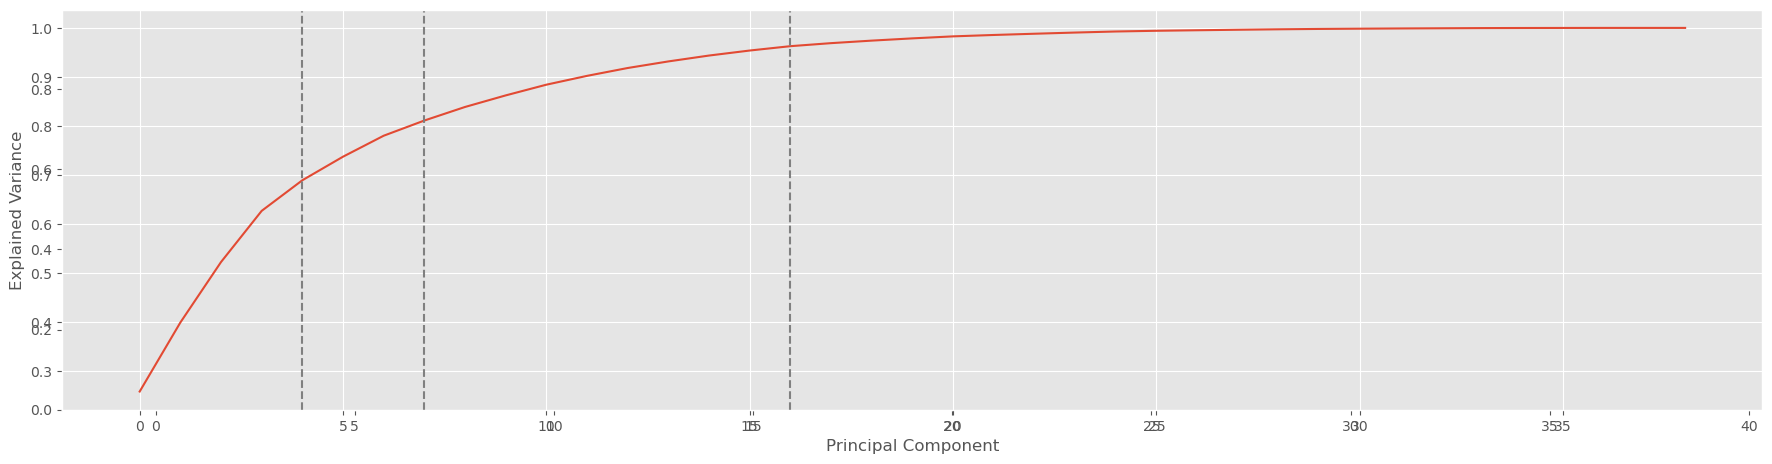

Minimum n_components required for 55% explained variance: 4
Minimum n_components required for 75% explained variance: 7
Minimum n_components required for 95% explained variance: 16


In [81]:
# Investigate the variance accounted for by each principal component

fig = plt.figure(figsize=(17,4))

ax1 = fig.add_axes([0,0,1,1])
ax1.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)

ax2 = fig.add_axes([0,0,1,1])
ax2.plot(np.cumsum(pca.explained_variance_ratio_))

ev_list = [0.55, 0.75, 0.95]
n_components_list = []

for ev in ev_list:
    n_components = min(np.where(np.cumsum(pca.explained_variance_ratio_)>ev)[0]+1)
    ax1.axhline(ev, linestyle='dashed', color='grey')
    ax2.axvline(n_components, linestyle='dashed', color='grey')
    n_components_list.append(n_components)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")

plt.show()

for ev, nc in zip(ev_list, n_components_list):
    print(f'Minimum n_components required for {int(ev*100)}% explained variance: {nc}')

The aim here is use a sufficient percentage to capture the majority of the variability in the data while keeping number of principal components reasonably small. In this particular case, since the original dataframe has only 39 features which in itself is small, 95% explained variance will be used.

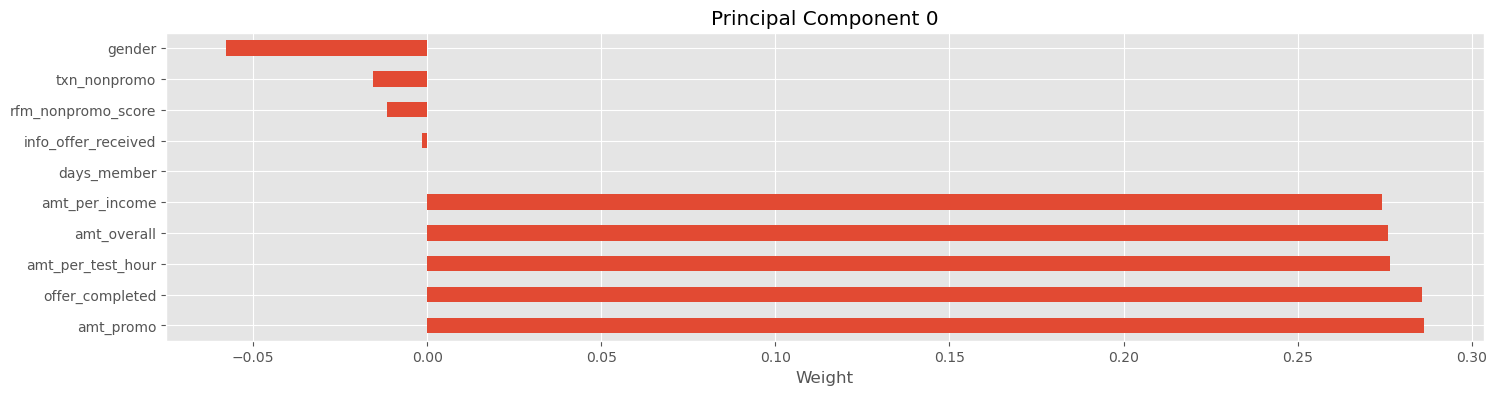

In [82]:
# Investigate the first principal component
u.plot_pca_component(coe, pca, 0)

The first principal component is associated largely with features in relation to customer's gender, amount spent in promotional durations, number offer completed, and also avengers spent per test hour and per income.

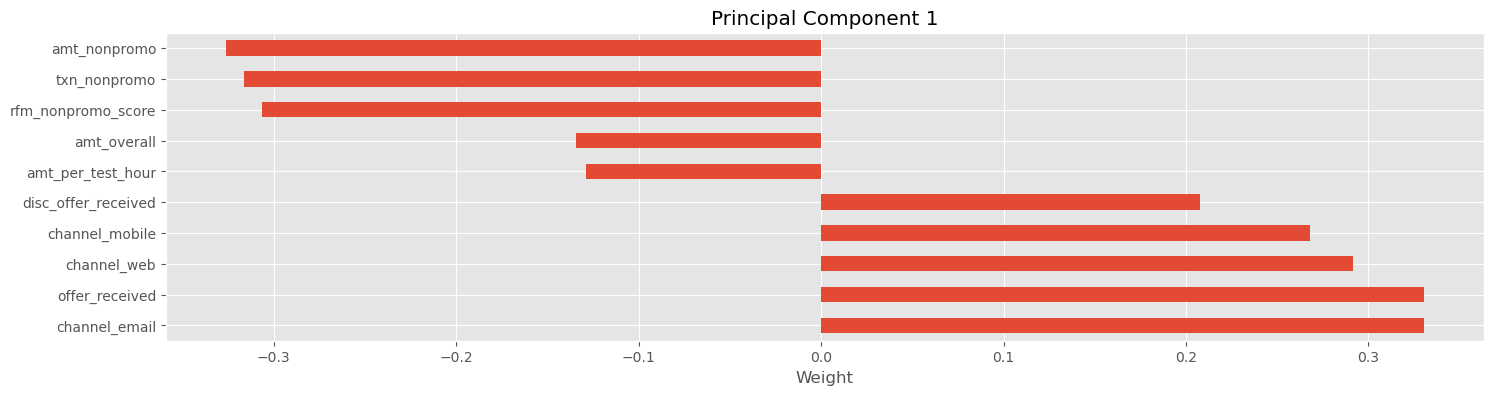

In [83]:
# Investigate the second principal component
u.plot_pca_component(coe, pca, 1)

The second principal component is largely associated with total number of offer received by a customer and their communication channels. Also, puts a lot of weight on activities outside of promotional durations.

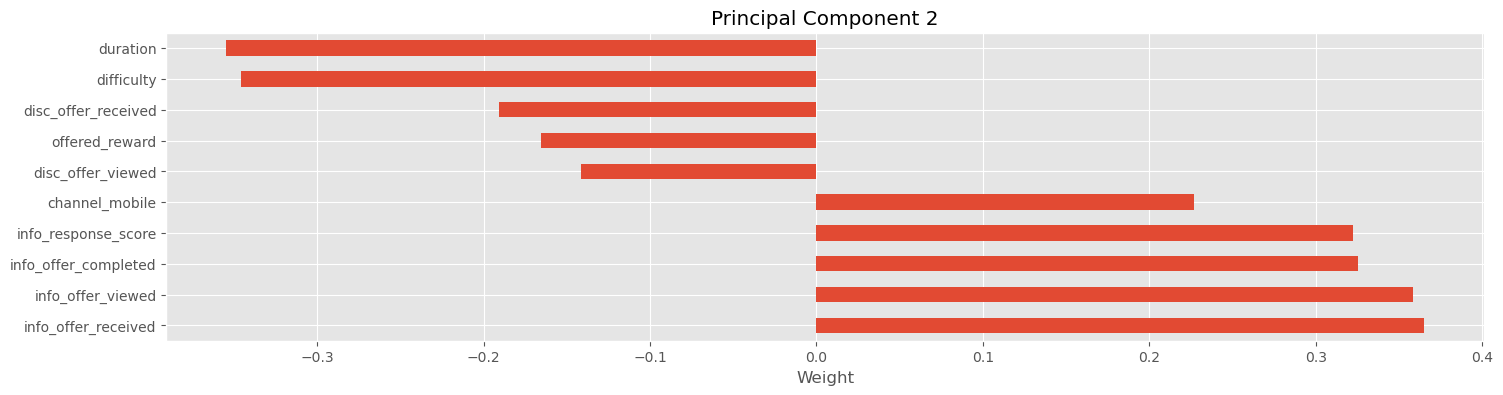

In [84]:
# Investigate the third principal component
u.plot_pca_component(coe, pca, 2)

The third principal component is largely associated with averages of duration and difficulty. Also with 'informational' offers features.

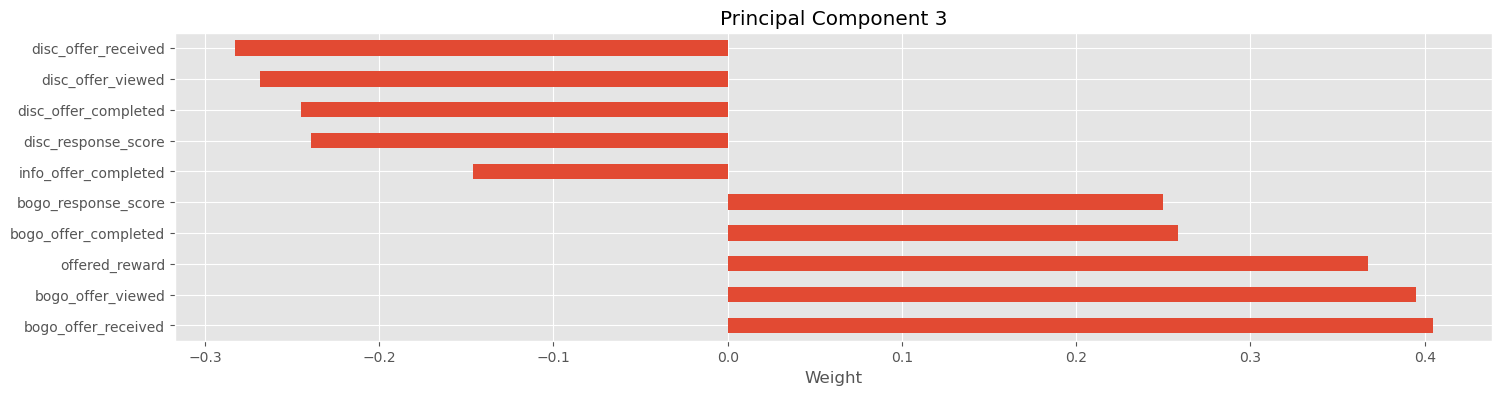

In [85]:
# Investigate the third principal component
u.plot_pca_component(coe, pca, 3)

The fourth principal component is largely associated with 'bogo' and 'discount' offers features.

### 4.2. Modeling & Evaluation

#### 4.2.1. Finding Optimal Number of Clusters

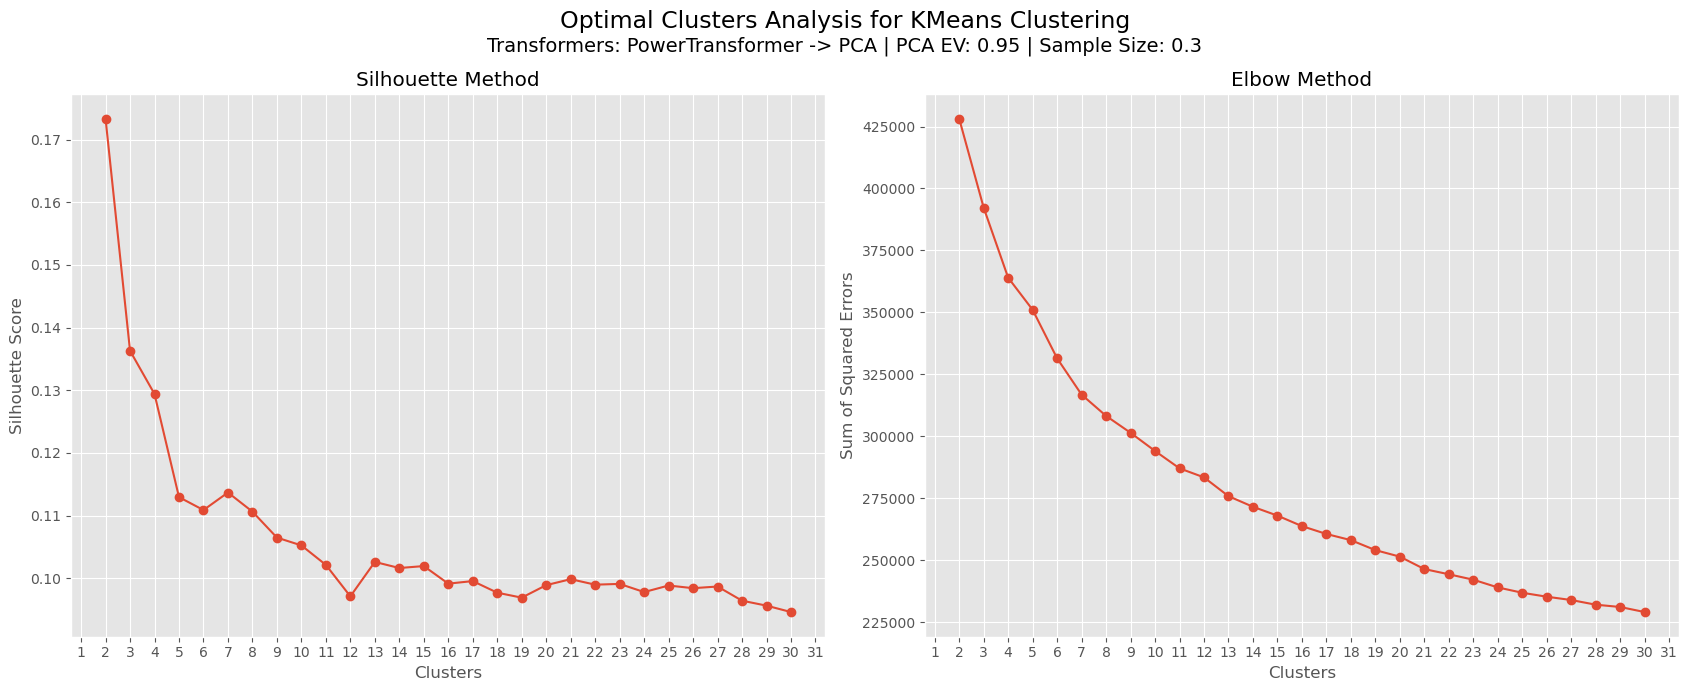

In [87]:
# Investigate change in SC and SSE across number of clusters
u.plot_optimization_analysis(
    df = coe,
    ev = 0.95,
    sample_size = 0.3)

First and foremost, the silhouette score is rather low indicating overlapping clusters (indifferent). The “elbow” method is not helpful in this case since there is no clear “elbow”. The silhouette method can be followed rigorously and thus making 2-3 the optimal number of clusters, or a compromise between the two methods can followed leading to an optimal number of 4-7 clusters.

#### 4.2.2. Performing Silhouette Analysis

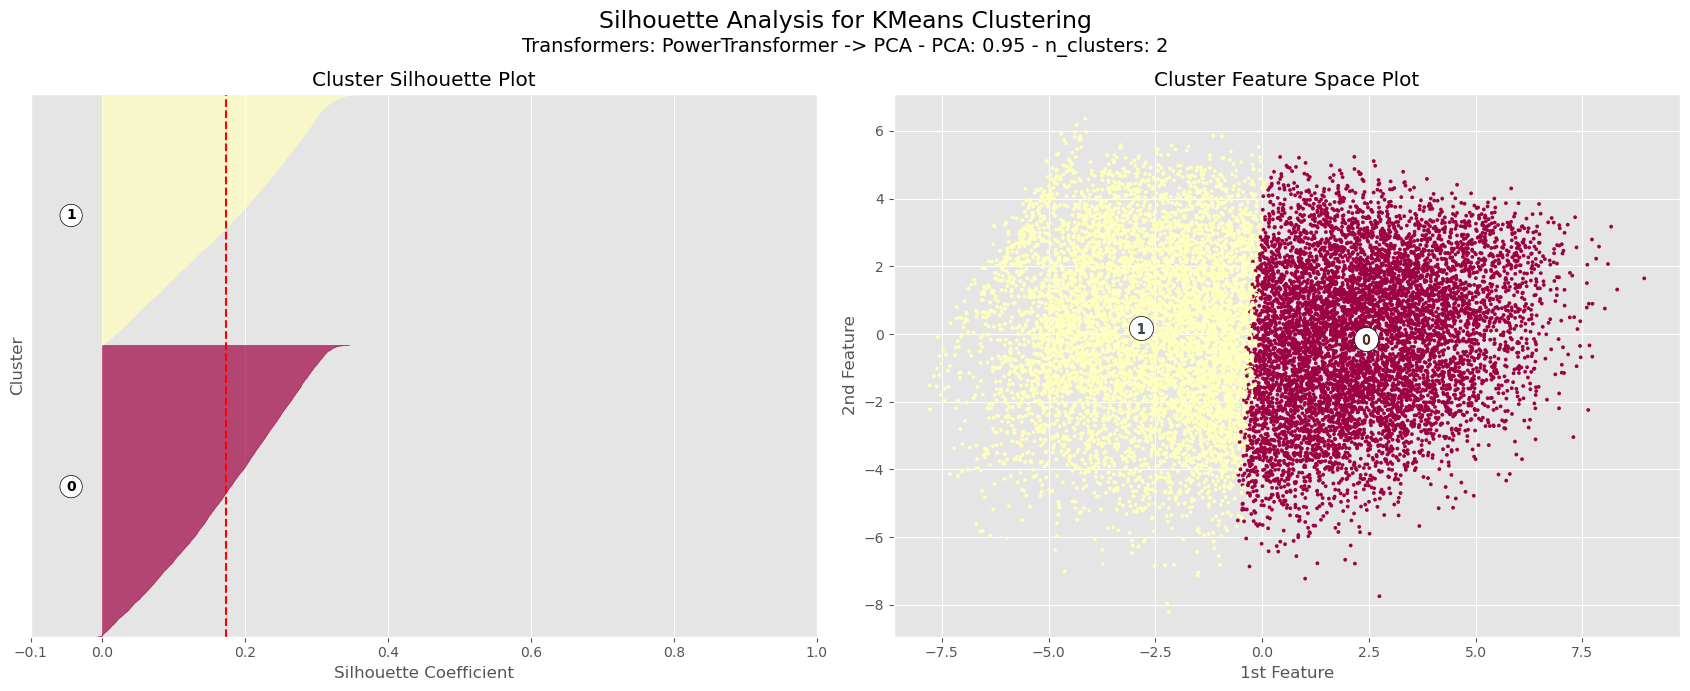

In [88]:
# Investigate silhouette analysis plot with n_clusters=2
u.plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 2)

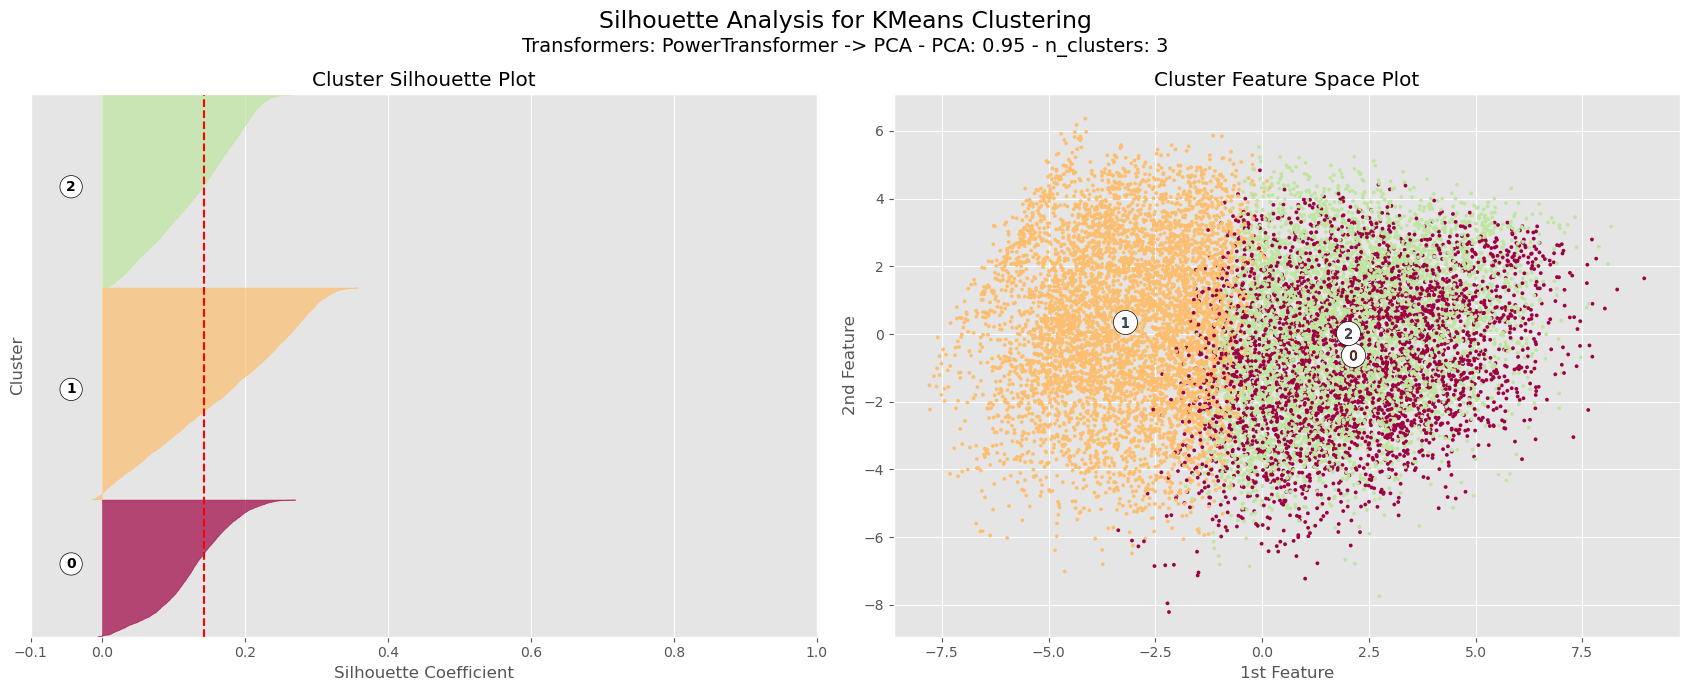

In [89]:
# Investigate silhouette analysis plot with n_clusters=3
u.plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 3)